# Low-level Linear Model in Pytorch

In [ ]:
!git clone https://github.com/vcsgmr/deeplearning.git
%cd deeplearning

In [23]:
from time import perf_counter

import numpy as np
import torch
from matplotlib import pyplot as plt

from idl.common import accuracy
from idl.week1.data import get_mnist, load_mnist, mnist_overview
from idl.week1.analysis import confusion_matrix, plot_learning_curves, precision_recall

## Getting Data

We will be training a model for the well-known MNIST dataset of handwritten digits. To do that, we have to download the dataset from one of the many mirrors available on the internet and unpack it manually. The result will be some `numpy` arrays.

This is based on [an official Pytorch tutorial](https://pytorch.org/tutorials/beginner/nn_tutorial.html).

In [4]:
get_mnist()
(x_train, y_train), (x_valid, y_valid), (x_test, y_test) = load_mnist()

MNIST images are 28x28 pixels, but they are actually stored as one-dimensional vectors; basically, the entire image is "unfolded" into a single row. That gives 28*28 = 784 pixels per image!
There are 50,000 training images, and 10,000 validation and testing images each.

It can also be a good idea to look at some statistics of the data a little bit. Here, we look at the overall pixel distribution (which values appear how often), as well as the label distribution.
We can see that MNIST is overwhelmingly 0, with some values at or close to 1, and very few values inbetween. Labels are almost, but not perfectly, balanced.

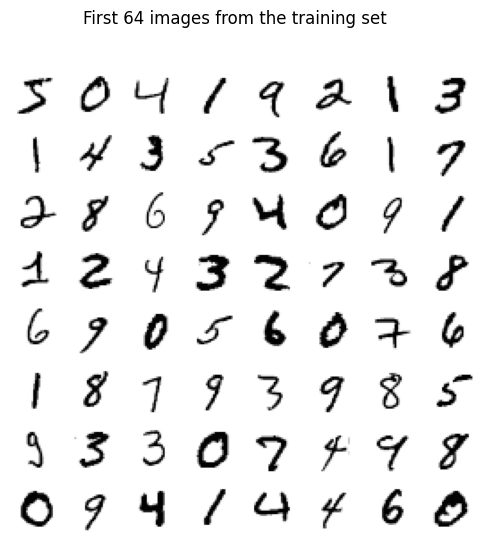

Training input shape (50000, 784); Validation input shape (10000, 784); Test input shape (10000, 784)
Training labels shape (50000,); Validation labels shape (10000,); Test labels shape (10000,)
Data Python type: Inputs <class 'numpy.ndarray'>; Labels <class 'numpy.ndarray'>
Data dtype: Inputs float32; Labels int64


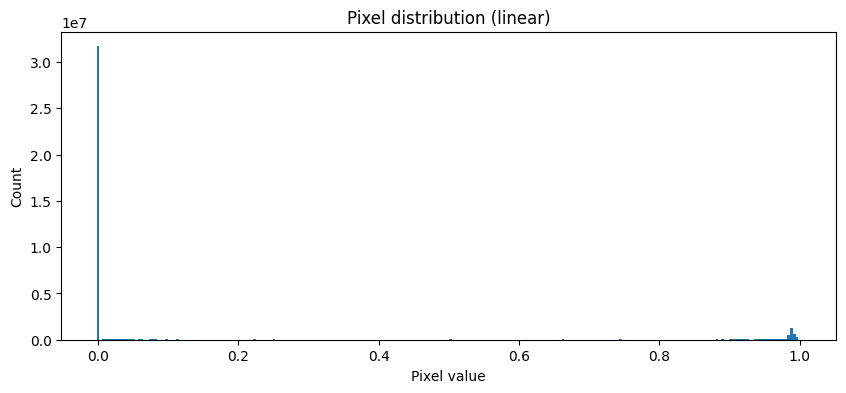

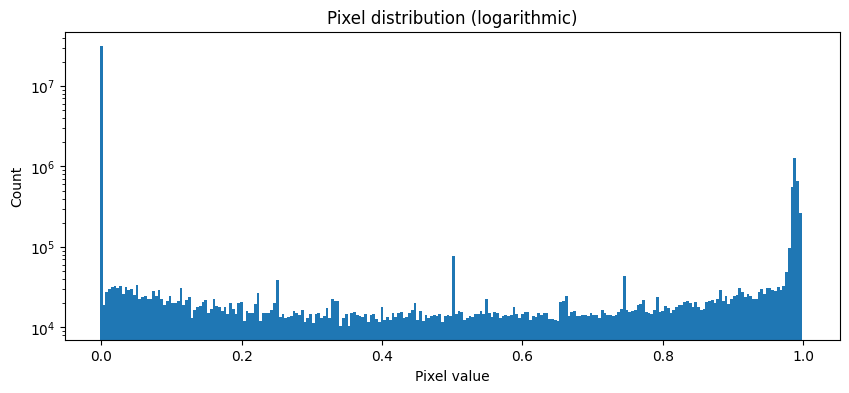

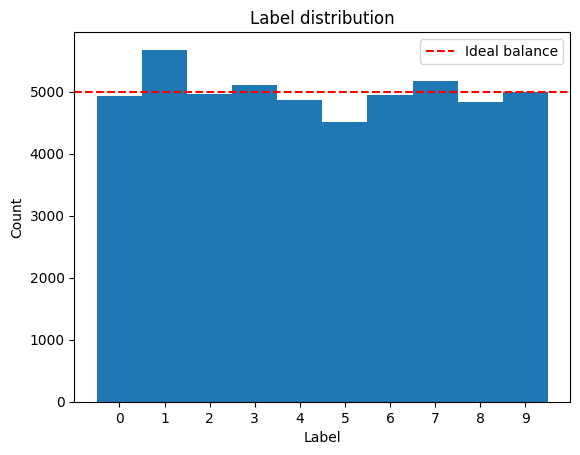

In [5]:
mnist_overview(x_train, y_train, x_valid, y_valid, x_test, y_test)

## Building a Model

A machine learning model generally consists of two main components:

1. A "forward function" that specifies how the input is turned into an output/prediction.
2. A set of parameters that influence the computations of the forward function.

Neural networks generally consist of a bunch of layers applied in sequence. The parameters are the weights of the layers.

Here, we define a `Model` class to encapsulate these properties. However, such simple models could easily be implemented without object-oriented programming, as well.

In [26]:
class Model:
    def __init__(self):
        # self.weights = torch.zeros(10, 784, requires_grad=True)
        self.weights1 = torch.distributions.Uniform(-0.01, 0.01).sample((128, 784)).requires_grad_()
        self.weights2 = torch.distributions.Uniform(-0.01, 0.01).sample((128, 128)).requires_grad_()
        self.weights3 = torch.distributions.Uniform(-0.01, 0.01).sample((10, 128)).requires_grad_()
        self.bias1 = torch.zeros(128, requires_grad=True)
        self.bias2 = torch.zeros(128, requires_grad=True)
        self.bias3 = torch.zeros(10, requires_grad=True)
        # example to create random weights instead.
        # you NEED this for MLPs! for linear models, 0s are fine.
        # biases are usually fine to initialize with 0s even for MLPs.
        #self.weights = torch.distributions.Uniform(-0.01, 0.01).sample((10, 784))


    def forward(self,
                inputs: torch.Tensor) -> torch.Tensor:
        h1 = inputs @ self.weights1.transpose(0, 1) + self.bias1
        h2 = h1 @ self.weights2.transpose(0, 1) + self.bias2
        logits = h2 @ self.weights3.transpose(0, 1) + self.bias3
        return softmax(logits)

    def __call__(self,
                 inputs: torch.Tensor) -> torch.Tensor:
        return self.forward(inputs)


def softmax(inputs: torch.Tensor) -> torch.Tensor:
    exponential = torch.exp(inputs)
    return exponential / exponential.sum(axis=-1, keepdims=True)


def cross_entropy(outputs: torch.Tensor,
                  labels: torch.Tensor) -> torch.Tensor:
    labels_one_hot = one_hot(labels, num_classes=10)
    return -(labels_one_hot * torch.log(outputs)).sum(axis=-1).mean()


def one_hot(inputs: torch.Tensor,
            num_classes: int | None = None) -> torch.Tensor:
    if num_classes is None:
        num_classes = inputs.max() + 1
    output = torch.zeros(inputs.shape[0], num_classes)
    output.scatter_(1, inputs.view(-1, 1), torch.ones(inputs.shape[0], 1))

    return output

We can try out the one-hot function:

In [7]:
print("Indices")
print(y_train[:5])
print()
print("One-hot")
print(one_hot(torch.tensor(y_train[:5])))

Indices
[5 0 4 1 9]

One-hot
tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])


Thanks to us defining a `__call__` function for our model, we can just call it like a function.
Here we test it on some example inputs.
Because all weights are initialized to 0, we get a perfectly uniform prediction every time!

Note that any time we call the model outside of training, we wrap it with `no_grad()` to make sure no gradients are accumulated/tracked.

In [27]:
linear_model = Model()

with torch.no_grad():
    print(linear_model(torch.tensor(x_train[:4])))

tensor([[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000]])


Similarly, the cross-entropy for one-hot labels and uniform prediction is always `ln(n_classes)`.
So in this case, `ln(10)`. `ln` is the natural logarithm.

In [9]:
with torch.no_grad():
    print(cross_entropy(linear_model(torch.tensor(x_train[:4])), torch.tensor(y_train[:4])))
np.log(10)

tensor(2.3026)


np.float64(2.302585092994046)

In [10]:
with torch.no_grad():
    print(accuracy(linear_model(torch.tensor(x_train[:4])), torch.tensor(y_train[:4])))

tensor(0.2500)


## Training

A simple training procedure goes as follows:
- Iterate over the training data in _batches_ with a chosen batch size. At each step:
  - Call the model on the input batch to get predictions
  - Compute the loss using the label batch and model predictions
  - Compute the gradient of the loss with respective to the model parameters
  - Update the parameters with the gradients
- Every so often, we should evaluate the model on the validation data using metrics of our choice, such as accuracy

Note that we could also update our `Model` class to make these methods part of the class.

In [11]:
def train_linear_model(model: Model,
                       training_data: tuple[np.ndarray, np.ndarray],
                       validation_data: tuple[np.ndarray, np.ndarray],
                       learning_rate: float,
                       batch_size: int,
                       n_epochs: int,
                       verbose: bool = True) -> dict[str, np.ndarray]:
    n_training_examples = len(training_data[0])
    batches_per_epoch = n_training_examples // batch_size
    print("Running {} epochs at {} steps per epoch.".format(n_epochs, batches_per_epoch))

    random_shuffling = np.arange(n_training_examples)

    train_input_tensor = torch.tensor(training_data[0])
    train_label_tensor = torch.tensor(training_data[1])
    valid_input_tensor = torch.tensor(validation_data[0])
    valid_label_tensor = torch.tensor(validation_data[1])

    # note, for training we only track the average over the epoch.
    # this is somewhat imprecise, as the model changes over the epoch.
    # so the metrics at the end of the epoch will usually be better than at the start,
    # but we average over everything.
    # we could record train metrics more often to get a better picture of training progress.
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(n_epochs):
        if verbose:
            print("Starting epoch {}...".format(epoch + 1), end=" ")
        start_time = perf_counter()

        # every epoch we shuffle the data!
        np.random.shuffle(random_shuffling)  # this shuffles in place
        shuffled_inputs = train_input_tensor[random_shuffling]
        shuffled_labels = train_label_tensor[random_shuffling]

        epoch_train_losses = []
        epoch_train_accuracies = []
        slice_index = 0

        for batch_ind in range(batches_per_epoch):
            input_batch = shuffled_inputs[slice_index:slice_index+batch_size]
            label_batch = shuffled_labels[slice_index:slice_index+batch_size]
            # this is the core of model training!
            # all the other stuff is pretty much just providing data and recording metrics...
            # two lines "forward" to compute outputs and the loss
            output_batch = model(input_batch)
            batch_loss = cross_entropy(output_batch, label_batch)
            # and then backpropagate
            batch_loss.backward()
            with torch.no_grad():
                model.weights -= model.weights.grad * learning_rate
                model.bias -= model.bias.grad * learning_rate
                model.weights.grad.zero_()
                model.bias.grad.zero_()

            batch_accuracy = accuracy(output_batch, label_batch)
            epoch_train_losses.append(batch_loss.item())
            epoch_train_accuracies.append(batch_accuracy.item())

            slice_index += batch_size
        end_time = perf_counter()
        time_taken = end_time - start_time

        # evaluate after each epoch
        with torch.no_grad():
            val_output = model(valid_input_tensor)
            val_loss = cross_entropy(val_output, valid_label_tensor)
            val_accuracy = accuracy(val_output, valid_label_tensor)
        val_losses.append(val_loss.item())
        val_accuracies.append(val_accuracy.item())

        train_losses.append(np.mean(epoch_train_losses))
        train_accuracies.append(np.mean(epoch_train_accuracies))

        if verbose:
            print(f"Time taken: {time_taken:.3f} seconds")
            print(f"\tTrain/val loss: {train_losses[-1]:.5g} / {val_losses[-1]:.5g}")
            print(f"\tTrain/val accuracy: {train_accuracies[-1]:.5g} / {val_accuracies[-1]:.5g}")
            print()

    return {"train_loss": np.array(train_losses), "train_accuracy": np.array(train_accuracies),
            "val_loss": np.array(val_losses), "val_accuracy": np.array(val_accuracies)}

In [12]:
metrics = train_linear_model(linear_model, (x_train, y_train), (x_valid, y_valid),
                             learning_rate=0.1, batch_size=128, n_epochs=15)

Running 15 epochs at 390 steps per epoch.
Starting epoch 1... Time taken: 0.587 seconds
	Train/val loss: 0.61372 / 0.38314
	Train/val accuracy: 0.85479 / 0.9004

Starting epoch 2... Time taken: 0.465 seconds
	Train/val loss: 0.3924 / 0.33572
	Train/val accuracy: 0.89319 / 0.9093

Starting epoch 3... Time taken: 0.451 seconds
	Train/val loss: 0.35669 / 0.3181
	Train/val accuracy: 0.90174 / 0.9131

Starting epoch 4... Time taken: 0.509 seconds
	Train/val loss: 0.33827 / 0.30774
	Train/val accuracy: 0.90575 / 0.9135

Starting epoch 5... Time taken: 0.514 seconds
	Train/val loss: 0.32626 / 0.29904
	Train/val accuracy: 0.90911 / 0.9166

Starting epoch 6... Time taken: 0.500 seconds
	Train/val loss: 0.31796 / 0.29396
	Train/val accuracy: 0.91096 / 0.9176

Starting epoch 7... Time taken: 0.475 seconds
	Train/val loss: 0.3115 / 0.28824
	Train/val accuracy: 0.91378 / 0.9188

Starting epoch 8... Time taken: 0.612 seconds
	Train/val loss: 0.30612 / 0.28572
	Train/val accuracy: 0.91494 / 0.9208

S

## Inspecting Model Performance

Basic things we can (and should pretty much always) look at are the loss/accuracy curves and a confusion matrix.

Note: With the training curves, it looks like not much is happening because the values are already pretty high after the first epoch. It would be possible to add another evaluation with the untrained model at the very start; this would show the actual learning better.

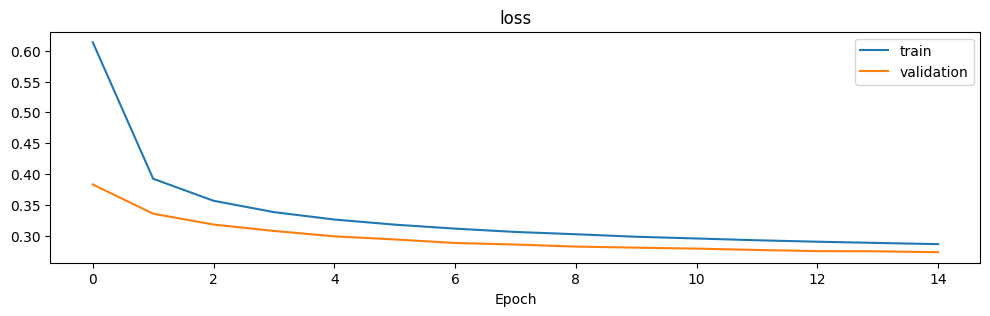

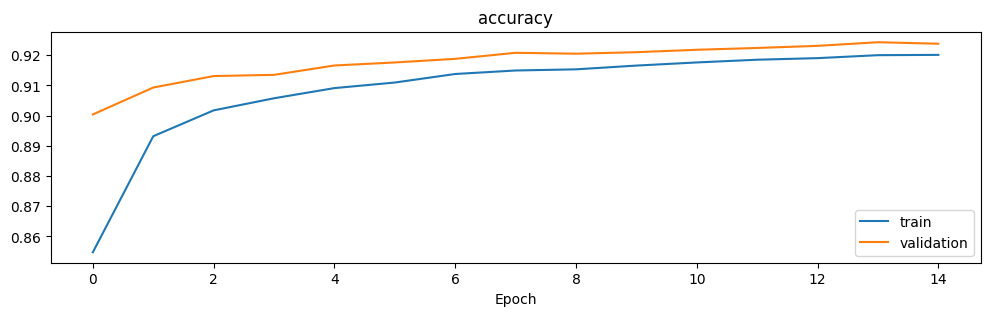

In [13]:
plot_learning_curves(metrics, keys=["loss", "accuracy"])

Below is a rudimentary implementation for a confusion matrix. We can see that the biggest sources of mistakes are confusions between 3 and 5, and between 4 and 9, 7 and 9 (but interestingly not 4 and 7) and 2, 3 and 8. In the latter case, 8s get misclassified as 2 or 3 more often than the other way around.

Note that the above observations are from our own model run. Your results may vary depending on training parameters and random factors.

In [14]:
training_matrix = confusion_matrix(linear_model, x_train, y_train)
np.set_printoptions(suppress=True)
print("Training confusion matrix")
print(training_matrix)

validation_matrix = confusion_matrix(linear_model, x_valid, y_valid)
print()
print("Validation confusion matrix")
print(validation_matrix)

Training confusion matrix
[[4756    1   18   14   11   39   38    4   46    5]
 [   1 5515   26   23    5   23    7   12   57    9]
 [  24   53 4437   82   72   24   64   66  127   19]
 [  11   24   95 4618    4  139   21   49  100   40]
 [   9   24   32    8 4522    4   57   12   33  158]
 [  54   30   28  167   52 3893   83   15  134   50]
 [  28   14   36    2   40   52 4741    4   32    2]
 [  18   33   71   18   49    8    3 4808   15  152]
 [  24   95   46  125   25  108   46    8 4312   53]
 [  23   28   16   73  140   29    4  149   44 4482]]

Validation confusion matrix
[[ 958    0    3    2    1    6    8    4    8    1]
 [   0 1037    4    6    1    5    1    2    8    0]
 [   3   10  888   14   15    6    9   13   25    7]
 [   7    3   14  922    1   42    4    5   23    9]
 [   1   11    2    1  931    0    8    3    5   21]
 [  12    2   15   37    7  785   29    6   17    5]
 [   2    1    8    0    9    7  936    0    4    0]
 [   7    6    8    8    6    1    0 1019  

A similar metric would be the per-class precision and recall. These can be computed from the confusion matrix. With some effort, it would also be possible to print/plot them at the edges of the matrix. :)

In [15]:
print("TRAINING")
precision_recall(training_matrix)

print("\n\nVALIDATION")
precision_recall(validation_matrix)

TRAINING
Class 0
Recall: 0.96431
Precision: 0.96120
Class 1
Recall: 0.97129
Precision: 0.94808
Class 2
Recall: 0.89312
Precision: 0.92341
Class 3
Recall: 0.90531
Precision: 0.90019
Class 4
Recall: 0.93064
Precision: 0.91911
Class 5
Recall: 0.86396
Precision: 0.90137
Class 6
Recall: 0.95758
Precision: 0.93622
Class 7
Recall: 0.92908
Precision: 0.93778
Class 8
Recall: 0.89054
Precision: 0.88000
Class 9
Recall: 0.89856
Precision: 0.90181


VALIDATION
Class 0
Recall: 0.96670
Precision: 0.96088
Class 1
Recall: 0.97462
Precision: 0.94016
Class 2
Recall: 0.89697
Precision: 0.93082
Class 3
Recall: 0.89515
Precision: 0.89776
Class 4
Recall: 0.94710
Precision: 0.93193
Class 5
Recall: 0.85792
Precision: 0.89714
Class 6
Recall: 0.96794
Precision: 0.93506
Class 7
Recall: 0.93486
Precision: 0.93658
Class 8
Recall: 0.89197
Precision: 0.89820
Class 9
Recall: 0.89698
Precision: 0.90356


For a linear model, each column of the weight matrix represents the weights for one of the output labels. The matrix multiplication between the input pixels and those weights computes a dot product for each possible label. This can be interpreted as a "score" for that class. Since the dot product is a similarity measure, i.e. it becomes larger the more similar the two vectors are, we can interpret the weights for each label as the "ideal input pattern" for that class that would maximize the score.

We can thus plot the 784 weights for each class, reshaped into image form. In this case, red pixels are "evidence for" the class (positive weights, increase the score), whereas blue pixels are "evidence against" (negative weights, reduce the score).

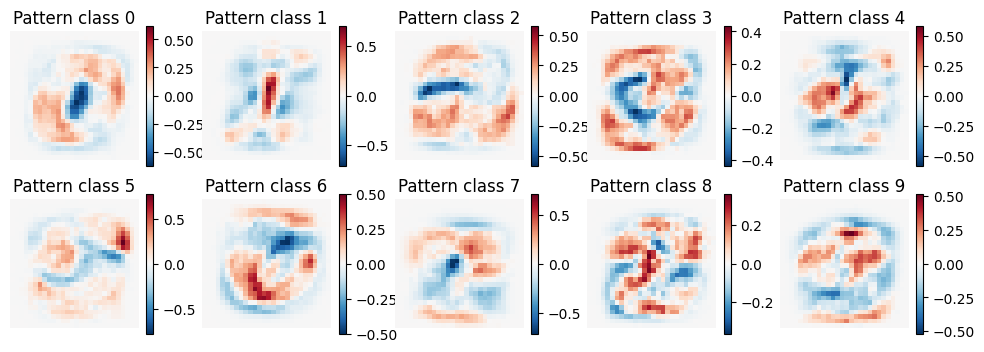

In [16]:
plt.figure(figsize=(12, 4))
for ind, pattern in enumerate(linear_model.weights.detach().numpy()):
    plt.subplot(2, 5, ind+1)
    absmax = abs(pattern).max()
    plt.imshow(pattern.reshape(28, 28), vmin=-absmax, vmax=absmax, cmap="RdBu_r")
    plt.axis("off")
    plt.colorbar()
    plt.title(f"Pattern class {ind}")
plt.show()

By inspecting the biases, we can look at what labels the model "prefers" absent any input data. However, these values are hard to interpret without the weights in a realistic scenario. For example, the largest bias is for class 5, yet this is actually the rarest class in the dataset, and so you might think it should have the lowest score a priori. There is also a strangely low bias for number 8, which might explain why it is mistaken for other digits so often.

Another explanation might relate to the number of pixels a digit usually consists of. A "small" digit doesn't have many active input pixels to drive a high score, so it might get a larger bias to compensate; the opposite could hold for a "large" digit that tends to have many active pixels.

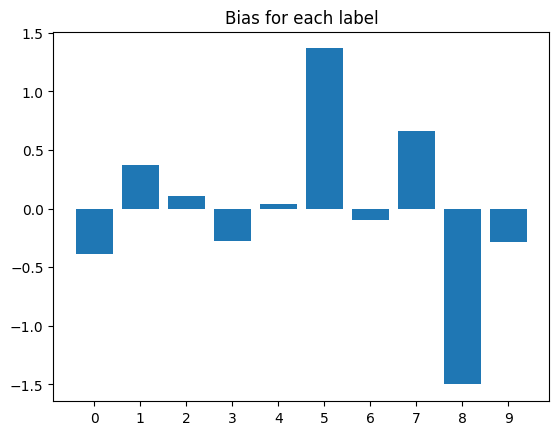

In [17]:
plt.bar(np.arange(10), linear_model.bias.detach().numpy())
plt.xticks(np.arange(10))
plt.title("Bias for each label")
plt.show()

## Basic Hyperparameter Study: Learning Rate

Most machine learning models have various _hyperparameters_, which are parameters that influence the model/training that we cannot train directly using our chosen learning method. In our case, examples are the batch size, learning rate, weight initialization or number of training steps. In a deep network, aspects of the architecture (number of layers, number of units per layer, choice of activation function...) are also hyperparameters.

Because we cannot train these parameters, we have to manually check for their influence by training models with various choices of hyperparameter values. The most important parameter tends to be the learning rate, so here we conduct a small study where we train models with different learning rates.

In [18]:
# to cover a large space, we commonly use so-called geometric progressions.
# this means there is a common *multipilicative* factor between successive values.
# here, each learning rate is roughly 3x the one before.
learning_rates = np.geomspace(0.0000001, 10., 17)
learning_rates

array([ 0.0000001 ,  0.00000032,  0.000001  ,  0.00000316,  0.00001   ,
        0.00003162,  0.0001    ,  0.00031623,  0.001     ,  0.00316228,
        0.01      ,  0.03162278,  0.1       ,  0.31622777,  1.        ,
        3.16227766, 10.        ])

In [19]:
all_metrics = {}
for lr_ind, learning_rate in enumerate(learning_rates):
    linear_model = Model()
    print(f"Training learning rate {learning_rate}...")
    metrics = train_linear_model(linear_model, (x_train, y_train), (x_valid, y_valid),
                                 learning_rate=learning_rate, batch_size=128, n_epochs=10,
                                 verbose=False)
    all_metrics[lr_ind] = metrics

Training learning rate 1e-07...
Running 10 epochs at 390 steps per epoch.
Training learning rate 3.162277660168379e-07...
Running 10 epochs at 390 steps per epoch.
Training learning rate 1e-06...
Running 10 epochs at 390 steps per epoch.
Training learning rate 3.162277660168379e-06...
Running 10 epochs at 390 steps per epoch.
Training learning rate 1e-05...
Running 10 epochs at 390 steps per epoch.
Training learning rate 3.1622776601683795e-05...
Running 10 epochs at 390 steps per epoch.
Training learning rate 0.0001...
Running 10 epochs at 390 steps per epoch.
Training learning rate 0.00031622776601683794...
Running 10 epochs at 390 steps per epoch.
Training learning rate 0.001...
Running 10 epochs at 390 steps per epoch.
Training learning rate 0.0031622776601683794...
Running 10 epochs at 390 steps per epoch.
Training learning rate 0.01...
Running 10 epochs at 390 steps per epoch.
Training learning rate 0.03162277660168379...
Running 10 epochs at 390 steps per epoch.
Training learnin

In [20]:
# collect the final results only
final_metrics = {"val_loss": [], "train_loss": [], "val_accuracy": [], "train_accuracy": []}
for ind in range(len(learning_rates)):
    lr_results = all_metrics[ind]
    for key in lr_results:
        final_metrics[key].append(lr_results[key][-1])

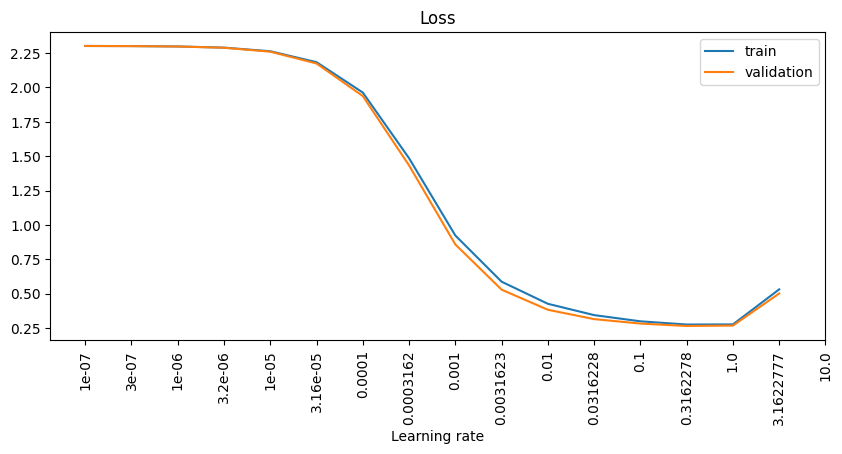

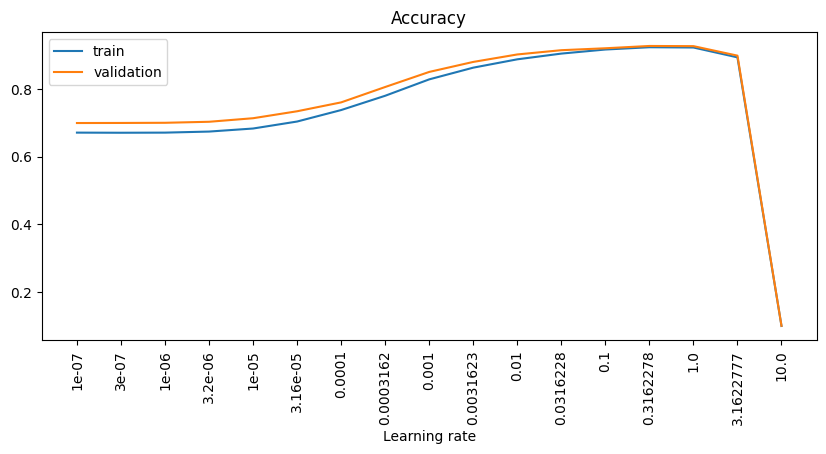

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(final_metrics["train_loss"], label="train")
plt.plot(final_metrics["val_loss"], label="validation")
plt.legend()
plt.title("Loss")
plt.xticks(np.arange(len(learning_rates)), np.round(learning_rates, 7), rotation="vertical")
plt.xlabel("Learning rate")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(final_metrics["train_accuracy"], label="train")
plt.plot(final_metrics["val_accuracy"], label="validation")
plt.legend()
plt.title("Accuracy")
plt.xticks(np.arange(len(learning_rates)), np.round(learning_rates, 7), rotation="vertical")
plt.xlabel("Learning rate")
plt.show()

We can also plot all the learning curves! This plot is not ideal, as some colors are repeating, so it's hard to differentiate all the different models. This would require some work choosing different colors and/or linestyles.

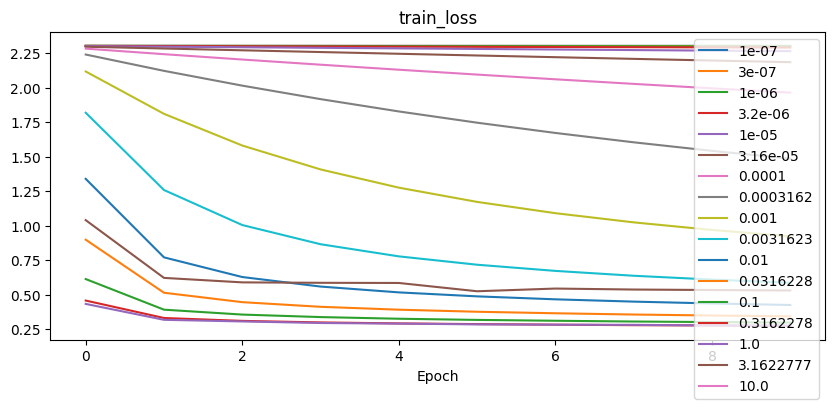

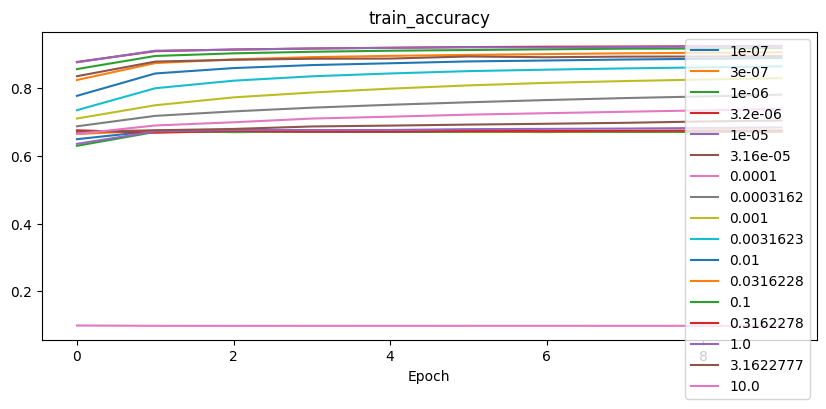

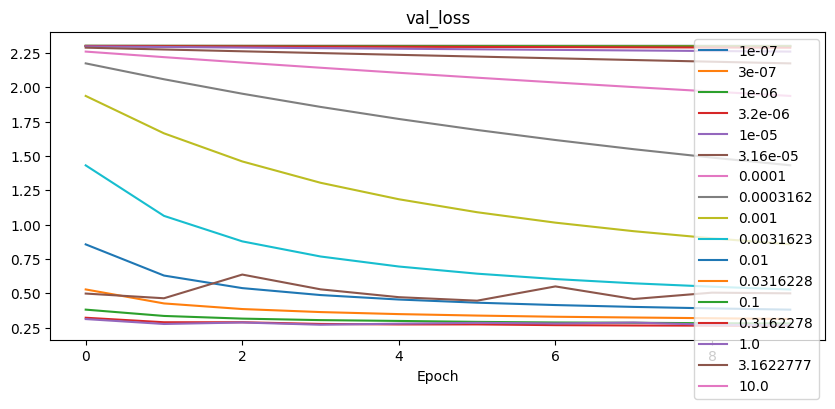

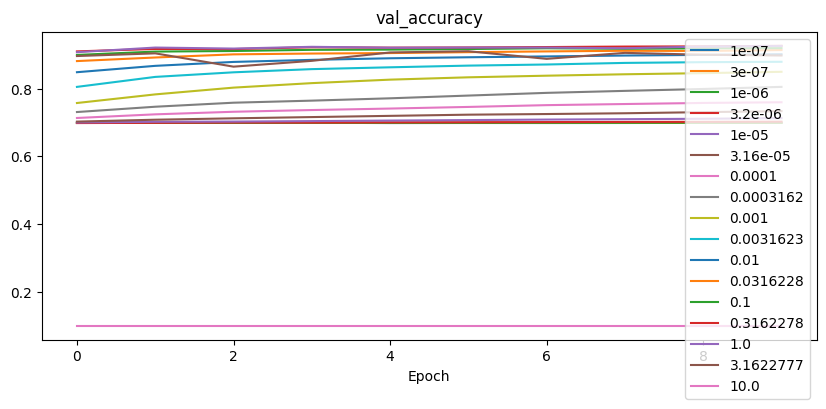

In [22]:
for key in lr_results:
    plt.figure(figsize=(10, 4))
    for ind, lr in enumerate(learning_rates):
        lr_results = all_metrics[ind]
        plt.plot(lr_results[key], label=str(np.round(lr, 7)))
    plt.title(key)
    plt.legend()
    plt.xlabel("Epoch")
    plt.show()